<a href="https://colab.research.google.com/github/johnsparz/ai-bootcamp-portfolio_2/blob/master/wk2_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **Used Car Price Prediction Using Linear Regression**



### **1.   Problem Understanding**



**Business Problem**

An online car marketplace wants to estimate the selling price of used cars automatically. Accurate price predictions help:



1.   Sellers list vehicles at competitive prices
2.   Buyers make informed purchasing decisions
1.   The marketplace improve pricing transparency





**Target Variable**:

Selling_Price

**Features**


*   Car_Name
*   Year
*   Present_Price
*   Kms_Driven
*   Fuel_Type
*   Seller_Type
*   Transmission
*   Owner





### **2.   Data Exploration (EDA)**



**Load Dataset**

In [70]:
import pandas as pd
csv_file_path = '/content/drive/My Drive/Car_data.csv'
df.head()

,Car_Name,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner,Car_Age
0,ritz,3.35,5.59,27000,Petrol,Dealer,Manual,0,11
1,sx4,4.75,9.54,43000,Diesel,Dealer,Manual,0,12
2,ciaz,7.25,9.85,6900,Petrol,Dealer,Manual,0,8
3,wagon r,2.85,4.15,5200,Petrol,Dealer,Manual,0,14
4,swift,4.60,6.87,42450,Diesel,Dealer,Manual,0,11


**Dataset Shape**

In [71]:
print(df.shape)

(301, 9)


**Missing Values**

In [72]:
df.isnull().sum()

,0
Car_Name,0
Selling_Price,0
Present_Price,0
Kms_Driven,0
Fuel_Type,0
Seller_Type,0
Transmission,0
Owner,0
Car_Age,0


**Summary Statistics**

In [73]:
df.describe()

,Selling_Price,Present_Price,Kms_Driven,Owner,Car_Age
count,301.000000,301.000000,301.000000,301.000000,301.000000
mean,4.661296,7.628472,36947.205980,0.043189,11.372093
std,5.082812,8.644115,38886.883882,0.247915,2.891554
min,0.100000,0.320000,500.000000,0.000000,7.000000
25%,0.900000,1.200000,15000.000000,0.000000,9.000000
50%,3.600000,6.400000,32000.000000,0.000000,11.000000
75%,6.000000,9.900000,48767.000000,0.000000,13.000000
max,35.000000,92.600000,500000.000000,3.000000,22.000000


**Visualizations**

**Selling Price Distribution**

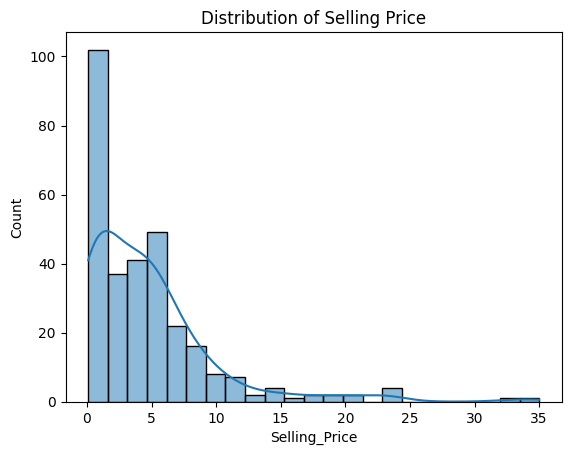

In [74]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(df["Selling_Price"], kde=True)
plt.title("Distribution of Selling Price")
plt.show()

**Selling Price vs Present Price**

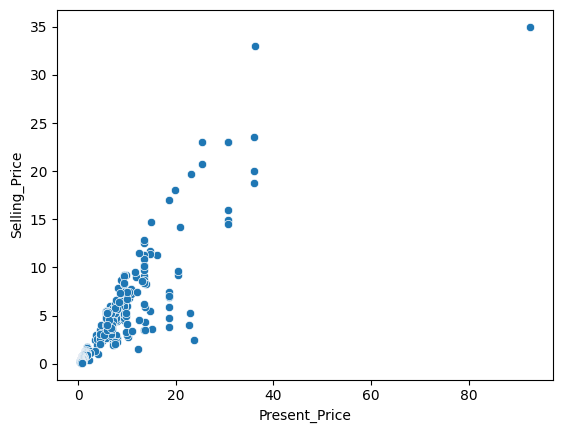

In [75]:
sns.scatterplot(
    x="Present_Price",
    y="Selling_Price",
    data=df
)
plt.show()

**Selling Price vs Kms Driven**

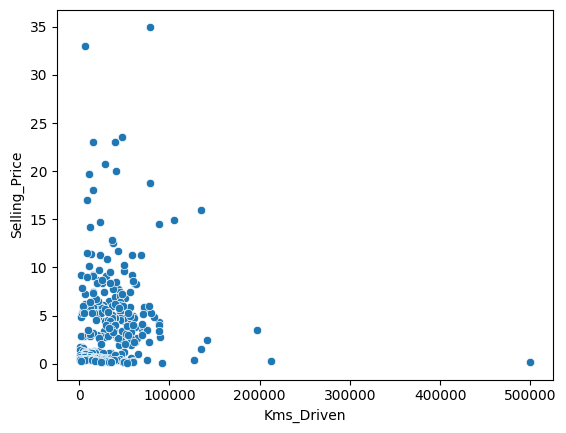

In [76]:
sns.scatterplot(
    x="Kms_Driven",
    y="Selling_Price",
    data=df
)
plt.show()

**Selling Price by Fuel Type**

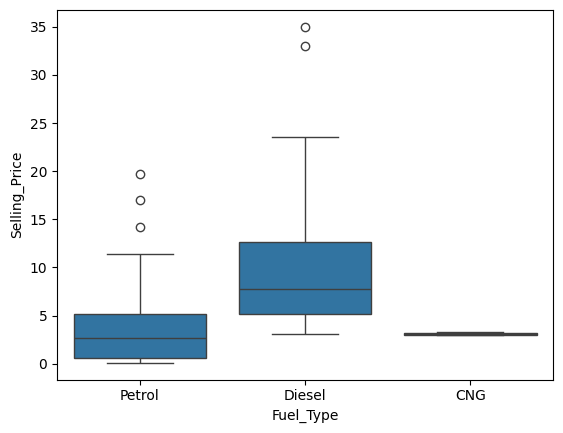

In [77]:
sns.boxplot(
    x="Fuel_Type",
    y="Selling_Price",
    data=df
)
plt.show()

**Correlation Heatmap**

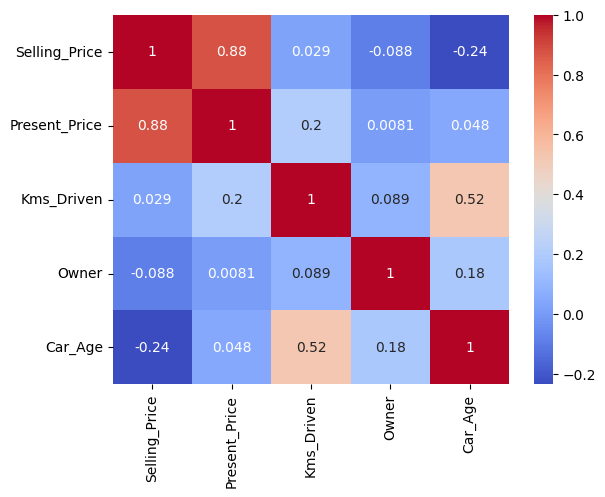

In [78]:
numeric_df = df.select_dtypes(include=["number"])

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm"
)
plt.show()



### **3.   Data Preprocessing**



**Feature Engineering**

Created a *Car_Age* feature and dropped *Year*

Downloaded the cleaned csv file

In [79]:
# df["Car_Age"] = 2025 - df["Year"]
# df.drop("Year", axis=1, inplace=True)

#df.to_csv("car_data_cleaned.csv", index=False)
#from google.colab import files
#files.download("car_data_cleaned.csv")

**Features and Target**

In [80]:
X = df.drop("Selling_Price", axis=1)
y = df["Selling_Price"]

**Identify Columns**

In [81]:
categorical_cols = X.select_dtypes(include="object").columns
numerical_cols = X.select_dtypes(exclude="object").columns

**Build Preprocessing Pipeline**

In [82]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", numeric_transformer, numerical_cols),
    ("cat", categorical_transformer, categorical_cols)
])

### **4.   Model Building**

**Train-Test Split**

In [83]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

**Linear Regression Model**

In [84]:
from sklearn.linear_model import LinearRegression

model = Pipeline([
    ("preprocessor", preprocessor),
    ("regressor", LinearRegression())
])

model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  Index(['Present_Price', 'Kms_Driven', 'Owner', 'Car_Age'], dtype='object')),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  Index(['Car_Name', 'Fuel_Type', 'Seller_Type', 'Transmission'], dtype='object'))])),
                ('regressor', LinearRegression())])

### **5.   Model Evaluation**

**Predictions**

In [85]:
y_pred = model.predict(X_test)

**Metrics**

In [86]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import numpy as np

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R²:", r2)

MAE: 1.1021419028508255
RMSE: 1.5123403020075237
R²: 0.9007113022436389


### **6.   Prediction for 5 Sample Cars**

In [87]:
sample_cars = X_test.head(5)

predictions = model.predict(sample_cars)

results = sample_cars.copy()
results["Predicted_Price"] = predictions

results

,Car_Name,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner,Car_Age,Predicted_Price
177,Honda Activa 125,0.57,24000,Petrol,Individual,Automatic,0,9,1.494467
289,city,13.60,10980,Petrol,Dealer,Manual,0,9,9.593118
228,verna,9.40,60000,Diesel,Dealer,Manual,0,13,5.505176
198,Bajaj Discover 125,0.57,35000,Petrol,Individual,Manual,1,14,-0.409631
60,corolla altis,18.61,40001,Petrol,Dealer,Manual,0,12,8.564932


### **7.   Insights**

#### **Factors That Most Influence Car Price**

**1. Present Price**

The strongest predictor of selling price.

Expensive cars when new tend to retain higher resale value.

**2. Car Age (Year)**

Newer cars generally sell for more.

**3. Transmission Type**

Automatic cars tend to command higher prices.

**4. Fuel Type**

Fuel type affects resale value due to operating costs and market demand.

**5. Brand/Car Name**

Some brands retain value better than others.


**Important Findings**


*   The dataset was completely clean and required no missing-value treatment.

*   Present Price and Selling Price show a very strong positive correlation.

*   One prediction was negative, highlighting a limitation of Linear Regression for price prediction.

